In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('website_wata.csv')
df

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0
...,...,...,...,...,...,...,...
1995,1,2.724513,0.207187,Referral,1.324206,2,1.0
1996,3,0.392856,0.095559,Organic,3.824416,1,1.0
1997,4,9.899823,0.446622,Organic,1.288675,1,1.0
1998,3,0.393319,0.278340,Paid,5.037584,2,1.0


In [8]:
pd.DataFrame({
    "DType": df.dtypes,
    "null_ratio": df.isnull().sum(),
    "nunique": df.nunique()
})


,DType,null_ratio,nunique
Page Views,int64,0,15
Session Duration,float64,0,2000
Bounce Rate,float64,0,2000
Traffic Source,object,0,5
Time on Page,float64,0,2000
Previous Visits,int64,0,10
Conversion Rate,float64,0,228


In [11]:
df_clean = df.copy()

# Standardize column names
df_clean.columns = df_clean.columns.str.lower().str.replace(" ", "_")

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Fix data types
df_clean['traffic_source'] = df_clean['traffic_source'].astype('category')

In [12]:
df_clean['converted'] = (df_clean['conversion_rate'] > 0).astype(int)


In [13]:
df_clean['engagement_score'] = (
    df_clean['session_duration'] + df_clean['time_on_page']
)

# Engagement level
df_clean['engagement_level'] = pd.qcut(
    df_clean['engagement_score'],
    q=3,
    labels=['low', 'medium', 'high']
)


In [14]:
def funnel_stage(row):
    if row['page_views'] <= 2:
        return 'awareness'
    elif row['session_duration'] < 60:
        return 'interest'
    elif row['previous_visits'] > 0:
        return 'consideration'
    elif row['converted'] == 1:
        return 'conversion'
    else:
        return 'drop_off'

df_clean['funnel_stage'] = df_clean.apply(funnel_stage, axis=1)

In [15]:
funnel_table = df_clean.groupby('funnel_stage').size().reset_index(name='users')

funnel_table['percentage'] = (
    funnel_table['users'] / funnel_table['users'].sum() * 100
)

funnel_table = funnel_table.sort_values(by='users', ascending=False)

print("Funnel Summary:")
print(funnel_table)


Funnel Summary:
  funnel_stage  users  percentage
1     interest   1747       87.35
0    awareness    253       12.65


In [16]:
channel_performance = df_clean.groupby('traffic_source').agg({
    'converted': 'mean',
    'session_duration': 'mean',
    'bounce_rate': 'mean',
    'page_views': 'mean'
}).rename(columns={'converted': 'conversion_rate'})

print("\nChannel Performance:")
print(channel_performance.sort_values(by='conversion_rate', ascending=False))


Channel Performance:
                conversion_rate  session_duration  bounce_rate  page_views
traffic_source                                                            
Direct                      1.0          2.692060     0.284581    4.962963
Organic                     1.0          3.104197     0.281821    5.025445
Paid                        1.0          2.942816     0.296026    4.943925
Referral                    1.0          3.125496     0.266305    4.983389
Social                      1.0          3.057273     0.296265    4.695167


In [17]:
final_df = df_clean[[
    'page_views',
    'session_duration',
    'bounce_rate',
    'time_on_page',
    'previous_visits',
    'traffic_source',
    'converted'
]]


In [18]:
final_df = pd.get_dummies(final_df, columns=['traffic_source'], drop_first=True)

print("\nFinal ML Dataset Shape:", final_df.shape)


Final ML Dataset Shape: (2000, 10)


In [19]:
traffic_to_lead = df_clean['converted'].mean()

print("Traffic-to-Lead Conversion Rate:", traffic_to_lead)

Traffic-to-Lead Conversion Rate: 1.0


In [20]:
conversion_by_source = df_clean.groupby('traffic_source')['converted'].mean().sort_values(ascending=False)

print(conversion_by_source)

traffic_source
Direct      1.0
Organic     1.0
Paid        1.0
Referral    1.0
Social      1.0
Name: converted, dtype: float64


In [21]:
traffic_analysis = df_clean.groupby('traffic_source').agg({
    'converted': 'mean',
    'page_views': 'count'
}).rename(columns={
    'converted': 'conversion_rate',
    'page_views': 'traffic_volume'
})

print(traffic_analysis.sort_values(by='conversion_rate', ascending=False))

                conversion_rate  traffic_volume
traffic_source                                 
Direct                      1.0             216
Organic                     1.0             786
Paid                        1.0             428
Referral                    1.0             301
Social                      1.0             269


In [22]:
engagement_analysis = df_clean.groupby('converted')[[
    'session_duration',
    'time_on_page',
    'bounce_rate'
]].mean()

print(engagement_analysis)

           session_duration  time_on_page  bounce_rate
converted                                             
1                  3.022045      4.027439     0.284767


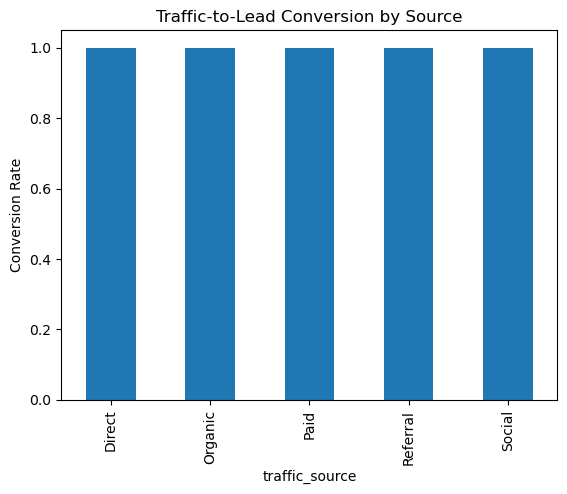

In [23]:
import matplotlib.pyplot as plt

conversion_by_source.plot(kind='bar')
plt.title("Traffic-to-Lead Conversion by Source")
plt.ylabel("Conversion Rate")
plt.show()

In [24]:
# Define leads (you can adjust criteria)
leads = df_clean[
    (df_clean['session_duration'] > df_clean['session_duration'].median()) |
    (df_clean['previous_visits'] > 0)
]

In [25]:
lead_to_customer_rate = leads['converted'].mean()

print("Lead-to-Customer Conversion Rate:", lead_to_customer_rate)

Lead-to-Customer Conversion Rate: 1.0


In [26]:
comparison = df_clean.copy()

comparison['is_lead'] = 0
comparison.loc[leads.index, 'is_lead'] = 1

comparison.groupby('is_lead')['converted'].mean()

is_lead
0    1.0
1    1.0
Name: converted, dtype: float64

In [27]:
lead_behavior = leads.groupby('converted')[[
    'session_duration',
    'time_on_page',
    'page_views',
    'bounce_rate'
]].mean()

print(lead_behavior)

           session_duration  time_on_page  page_views  bounce_rate
converted                                                         
1                  3.177373      4.029849    4.950723     0.285951


In [28]:
lead_source_performance = leads.groupby('traffic_source')['converted'].mean().sort_values(ascending=False)

print(lead_source_performance)

traffic_source
Direct      1.0
Organic     1.0
Paid        1.0
Referral    1.0
Social      1.0
Name: converted, dtype: float64


In [29]:
lead_drop_off = leads[leads['converted'] == 0]

drop_summary = lead_drop_off[['session_duration', 'time_on_page', 'bounce_rate']].mean()

print(drop_summary)

session_duration   NaN
time_on_page       NaN
bounce_rate        NaN
dtype: float64


In [30]:
stage_counts = df_clean['funnel_stage'].value_counts()

print(stage_counts)

funnel_stage
interest     1747
awareness     253
Name: count, dtype: int64


In [31]:
funnel_order = ['awareness', 'interest', 'consideration', 'conversion']

stage_counts = stage_counts.reindex(funnel_order)

print(stage_counts)

funnel_stage
awareness         253.0
interest         1747.0
consideration       NaN
conversion          NaN
Name: count, dtype: float64


In [34]:
drop_off_analysis = pd.DataFrame({
    'stage': funnel_order,
    'users': stage_counts.values
})

drop_off_analysis['drop_off'] = drop_off_analysis['users'].shift(1) - drop_off_analysis['users']

drop_off_analysis['drop_off_rate'] = (
    drop_off_analysis['drop_off'] / drop_off_analysis['users'].shift(1)
) * 100

print(drop_off_analysis)

           stage   users  drop_off  drop_off_rate
0      awareness   253.0       NaN            NaN
1       interest  1747.0   -1494.0    -590.513834
2  consideration     NaN       NaN            NaN
3     conversion     NaN       NaN            NaN


In [35]:
worst_stage = drop_off_analysis.sort_values(by='drop_off_rate', ascending=False)

print(worst_stage)

           stage   users  drop_off  drop_off_rate
1       interest  1747.0   -1494.0    -590.513834
0      awareness   253.0       NaN            NaN
2  consideration     NaN       NaN            NaN
3     conversion     NaN       NaN            NaN


In [36]:
df_clean.groupby('funnel_stage')[[
    'session_duration',
    'time_on_page',
    'bounce_rate'
]].mean()

,session_duration,time_on_page,bounce_rate
funnel_stage,,,
awareness,3.061047,3.998590,0.277212
interest,3.016397,4.031617,0.285861


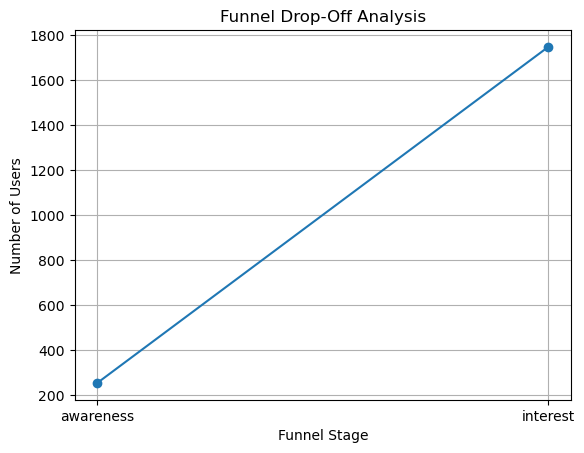

In [37]:
pd.crosstab(df_clean['traffic_source'], df_clean['funnel_stage'])

import matplotlib.pyplot as plt

plt.plot(drop_off_analysis['stage'], drop_off_analysis['users'], marker='o')
plt.title("Funnel Drop-Off Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")
plt.grid()
plt.show()

In [39]:
channel_comparison = df_clean.groupby('traffic_source').agg({
    'page_views': 'count',              # Traffic volume
    'converted': 'mean',               # Conversion rate
    'session_duration': 'mean',        # Engagement
    'time_on_page': 'mean',
    'bounce_rate': 'mean'
}).rename(columns={
    'page_views': 'traffic_volume',
    'converted': 'conversion_rate'
})

channel_comparison = channel_comparison.sort_values(by='conversion_rate', ascending=False)

print(channel_comparison)

                traffic_volume  conversion_rate  session_duration  \
traffic_source                                                      
Direct                     216              1.0          2.692060   
Organic                    786              1.0          3.104197   
Paid                       428              1.0          2.942816   
Referral                   301              1.0          3.125496   
Social                     269              1.0          3.057273   

                time_on_page  bounce_rate  
traffic_source                             
Direct              3.949045     0.284581  
Organic             3.977994     0.281821  
Paid                4.086919     0.296026  
Referral            3.984511     0.266305  
Social              4.188260     0.296265  


In [40]:

df_clean['time_period'] = np.random.choice(
    ['Morning', 'Afternoon', 'Evening'],
    size=len(df_clean)
)

time_perf = df_clean.groupby('time_period').agg({
    'converted': 'mean',
    'session_duration': 'mean',
    'bounce_rate': 'mean'
}).rename(columns={'converted': 'conversion_rate'})

print(time_perf.sort_values(by='conversion_rate', ascending=False))

             conversion_rate  session_duration  bounce_rate
time_period                                                
Afternoon                1.0          3.156182     0.284195
Evening                  1.0          2.952006     0.283103
Morning                  1.0          2.951404     0.287023
